# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | bare Python triple loops | sequential timing baseline; its O(N²) cost caps the speedup sweep at N = 4096 |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |
| `GpuV3` | fused FlashAttention-1 forward | one kernel, resident Q tile, online softmax — the N×N matrix never exists |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

`CpuPipeline` is the deliberately sequential reference: attention runs as
bare Python triple loops — no BLAS, no SIMD, no threads — while every other
stage stays in PyTorch. Profiling its forward pass (Chart 1) makes the
target unambiguous: the interpreted $O(N^2 D)$ attention owns ~95% of the
pass at $N = 64$ and ~99%+ everywhere above, and it is the only step whose
cost grows quadratically with N. Its runtime is also what caps the speedup
sweep: ~$30$ min per attention pass at $N = 4096$.

In [2]:
# Correctness gate: the CPU baseline must match torch's SDPA oracle before
# it can serve as the profiling / timing reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    # fp64 python floats vs fp32 torch
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x),
                               atol=1e-4, rtol=1e-3)
print("CpuPipeline matches the torch SDPA oracle")

CpuPipeline matches the torch SDPA oracle


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-08-06 05:19:58 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:19:58 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:19:58 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:19:59 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:19:59 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:20:03 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:20:03 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:20:26 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:20:26 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:22:10 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:22:11 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:29:08 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:29:08 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:39 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


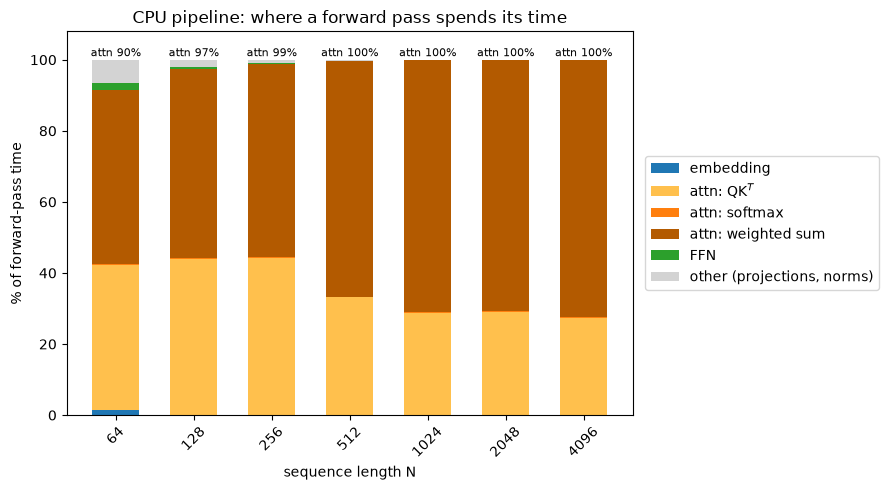

In [3]:
# Chart 1 -- share of forward-pass time per step (all-PyTorch pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 13)]
# warmup=False: pure python, nothing to JIT, and a pass costs minutes
pcts = [bench.step_percentages(cpu_model, n, warmup=False) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("CPU pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Three versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse; V3 changes the algorithm so the traffic V2 was
economising never exists at all.

**V1 — naive three-launch** (`gpu_v1.py`): `_matmul` (QK$^T$, with the
$1/\sqrt{D}$ scale fused into the epilogue), `_softmax`, `_matmul`
(weights·V) — and every intermediate including the full N×N score matrix
round-trips through global memory. The matmul loads are coalesced (adjacent
threads read adjacent addresses) but nothing is reused, and the softmax
uses one block per row with a coalesced read but still passes over the row
three times (max, sum, write); V2 folds those into one pass.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from
global memory 16× less often; shared arrays are padded to dodge bank
conflicts) and fuses the $1/\sqrt{D}$ scaling into the epilogue.
`_softmax_online` uses one block per row: a running (max, sum) pair
rescaled when the max moves — the log-sum-exp trick — gets both out of
**one** coalesced read of the row.

**V3 — fused FlashAttention-1 forward** (`gpu_v3.py`): the whole step in one
kernel, and the $N \times N$ score matrix never exists in any memory. Each
block stages its 16-row Q tile in shared memory *once* and keeps it resident
while sweeping the K/V tiles — Q traffic drops from $O(N^2 D)$ to $O(N D)$.
Per 16×16 tile: the score tile $S = QK^T/\sqrt{D}$ is a shared-memory block
matmul (K and V staged chunk by chunk with exactly V2's tiling idiom — no
prefetching, no unrolling); then Algorithm 1 of the FlashAttention paper
runs verbatim — the tile's row max $\tilde{m}$ and sum $\tilde{l}$ merge
into the running $(m, l)$, and the output block is rescaled *and
renormalised* on the spot, so it always holds the exact softmax-weighted sum
of every key seen so far. Where V2 economised the N×N traffic, V3 deletes
it — at the price of one rescale-divide per tile, which FA-2 later showed
how to defer.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [4]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV2: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV3: matches torch SDPA within 1e-4


### Distribution shift — the bottleneck moves back

Same buckets for all four pipelines: attention as a single step, since the
GPU versions don't split it into sub-steps (and their attention time includes
the CPU↔GPU transfers — the honest cost of the swap); the all-PyTorch panel
reuses Chart 1's measurements. Moving attention to the GPU flips Chart 1: the
$O(N^2)$ step drops out of the distribution and the forward pass belongs to
the linear PyTorch steps again — until the $O(N^2)$ kernel time starts
creeping back in at the top of the sweep, the same scaling argument one level
down. V1, V2 and V3 differ only in the attention band, so each faster kernel
is directly visible as a thinner orange stripe.

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:41 5245:5245 Activi

USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:41 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:42 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-06 05:58:43 5245:5245 Activit

USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-06 05:58:43 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:44 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


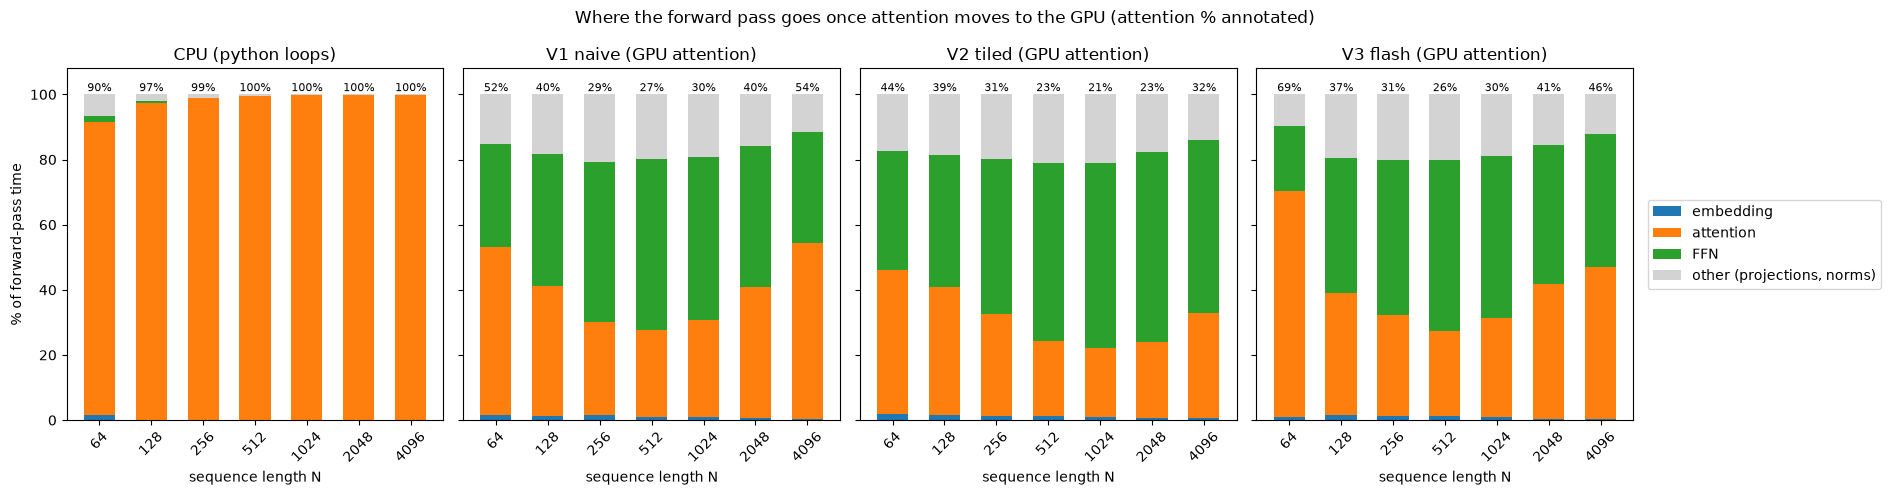

In [5]:
# Chart 1b -- step-time distribution per pipeline (coarse buckets, all comparable)
if cuda.is_available():
    # torch panel reuses Chart 1's profile: the sub-steps sum to the attention total
    dist = {"CPU (python loops)": [
        {"1_embedding": p["1_embedding"],
         "2_attention_total": sum(p[s] for s in bench.ATTN_STEPS),
         "3_ffn": p["3_ffn"], "other": p["other"]} for p in pcts]}
    for title, m in (("V1 naive (GPU attention)", GpuV1().eval()),
                     ("V2 tiled (GPU attention)", GpuV2().eval()),
                     ("V3 flash (GPU attention)", GpuV3().eval())):
        dist[title] = [bench.step_percentages(m, n, steps=bench.STEPS_TOTAL)
                       for n in PROFILE_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks the GPU passes leave cached

    parts = bench.STEPS_TOTAL + ["other"]
    names = {"1_embedding": "embedding", "2_attention_total": "attention",
             "3_ffn": "FFN", "other": "other (projections, norms)"}
    colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
              "3_ffn": "tab:green", "other": "lightgray"}

    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(PROFILE_LENS))
    for ax, (title, ps) in zip(axes, dist.items()):
        bottom = np.zeros(len(PROFILE_LENS))
        for part in parts:
            vals = np.array([p[part] for p in ps])
            ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
            bottom += vals
        for xi, p in zip(xpos, ps):  # annotate the attention share
            ax.text(xi, 101, f"{p['2_attention_total']:.0f}%", ha="center", fontsize=8)
        ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.set_ylim(0, 108)
    axes[0].set_ylabel("% of forward-pass time")
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.suptitle("Where the forward pass goes once attention moves to the GPU (attention % annotated)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the combined step-share chart")

## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v. The GPU
columns *include* the CPU→GPU→CPU transfers — the true cost of swapping a
kernel into an otherwise-CPU pipeline. N sweeps the powers of two from
$2^6$ to $2^{12}$ (64 → 4096), covering every spec checkpoint
(128 / 512 / 2048); the top is set by the python-loop baseline, whose
$O(N^2 D)$ interpreter cost reaches ~27 min per pass at $N = 4096$. A
calibration pass projects that cost and warns when a sequence length would
not be feasible (cell timeout or RAM). The CPU column is one profiled pass
per point, which also yields the three sub-step times reused as Chart 2's
baselines. The kernel-only sweep below runs GPU-only, so it extends to
$2^{14}$ for the memory and throughput analyses.

In [6]:
SEQ_LENS = [2 ** x for x in range(6, 13)]   # speedup sweep: capped by the CPU
KERNEL_LENS = [2 ** x for x in range(6, 15)]   # GPU-only analyses sweep further

if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # feasibility guard: the baseline is interpreted python with O(N^2 D)
    # cost -- calibrate one pass, project the sweep top against the cell
    # timeout and available RAM
    import os
    cal_ms = bench.attention_ms(cpu_model, 256, reps=1, warmup=False)
    proj_s = cal_ms * (SEQ_LENS[-1] / 256) ** 2 / 1e3
    ram = os.sysconf("SC_PHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    need = 2 * SEQ_LENS[-1] ** 2 * 32  # scores + weights as python float lists
    if proj_s > 3300 or need > 0.6 * ram:
        print(f"WARNING: N = {SEQ_LENS[-1]} may not be feasible on the python "
              f"baseline: projected ~{proj_s / 60:.0f} min per attention pass, "
              f"~{need / 1e9:.1f} GB of {ram / 1e9:.0f} GB RAM")

    # CPU measured last (slowest by far): one profiled pass per point yields
    # the per-step times (Chart 2's baselines) and their sum, the CPU column
    cpu_steps = [bench.attention_step_ms(cpu_model, n) for n in SEQ_LENS]
    times = {"CPU": [sum(d.values()) for d in cpu_steps], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green"}

USDT:2026-08-06 05:58:51 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:51 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:51 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:52 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:52 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:58:57 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:58:57 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 05:59:19 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 05:59:19 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 06:01:02 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 06:01:02 5245:5245 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-06 06:07:55 5245:5245 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-06 06:07:55 5245:5245 ActivityProfilerController.cpp:415] profiler_start


     N                          CPU                    V1 naive   V2 tiled + online softmax              V3 flash fused
-----------------------------------------------------------------------------------------------------------------------
    64                    252.15 ms                     1.83 ms                     1.72 ms                     1.24 ms
   128                    999.87 ms                     2.02 ms                     1.92 ms                     1.63 ms
   256                   5086.37 ms                     2.59 ms                     2.38 ms                     2.38 ms
   512                  21819.36 ms                     4.04 ms                     3.44 ms                     3.93 ms
  1024                 102681.73 ms                    10.14 ms                     6.48 ms                    10.82 ms
  2048                 412467.12 ms                    39.63 ms                    17.74 ms                    34.87 ms
  4096                1797834.19 ms     

USDT:2026-08-06 06:37:54 5245:5245 ActivityProfilerController.cpp:455] profiler_stop


## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Following the HW02 methodology: **device-resident timing with CUDA events**, so
the timed region is pure compute — no CPU→GPU→CPU copy. This isolates kernel
speed from the pipeline-boundary tax that the end-to-end sweep pays.

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident) -- GPU-only, so it
# runs past the CPU-capped benchmark to N = 2^14 for Charts 3-5
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in KERNEL_LENS]
              for name, m in kmodels.items()}
    # per-step kernel times (QK^T, softmax, weighted sum) for Chart 2 --
    # only the unfused versions expose the three step methods (V3 is one kernel)
    ksteps = {name: [bench.attention_kernel_step_ms(m, n, reps=10) for n in KERNEL_LENS]
              for name, m in kmodels.items() if "_step_qkt" in type(m).__dict__}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(KERNEL_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: Tesla T4 | 40 SMs



     N                      V1 naive     V2 tiled + online softmax                V3 flash fused   (kernel-only ms)
------------------------------------------------------------------------------------------------
    64                      1.356 ms                      1.263 ms                      0.629 ms
   128                      1.347 ms                      1.246 ms                      0.651 ms
   256                      1.348 ms                      1.237 ms                      0.901 ms
   512                      1.769 ms                      1.281 ms                      1.701 ms
  1024                      7.768 ms                      3.050 ms                      7.403 ms
  2048                     34.873 ms                     14.160 ms                     28.805 ms
  4096                    152.071 ms                     63.839 ms                    100.337 ms
  8192                    620.319 ms                    254.167 ms                    372.454 ms
 16384    

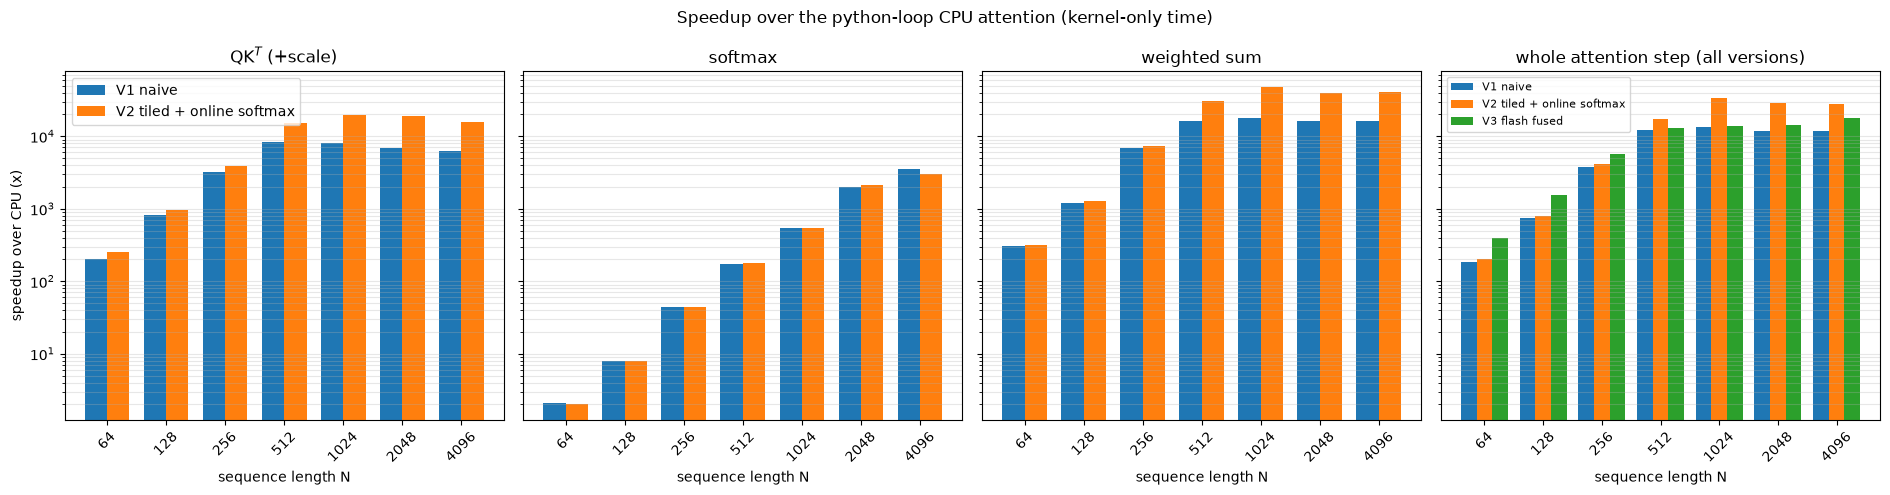

In [8]:
# Chart 2 -- speedup over the python-loop CPU attention: per sub-step for
# the unfused versions, then the whole step for all three (V3 is a single
# fused kernel, so whole-step granularity only)
if cuda.is_available():
    step_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
                  "2c_value_weighted_sum": "weighted sum"}
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(SEQ_LENS))
    w = 0.76 / len(ksteps)
    offs = (np.arange(len(ksteps)) - (len(ksteps) - 1) / 2) * w
    for ax, (step, title) in zip(axes, step_names.items()):
        for off, (name, ks) in zip(offs, ksteps.items()):
            kmap = dict(zip(KERNEL_LENS, ks))
            speedups = [c[step] / kmap[n][step] for c, n in zip(cpu_steps, SEQ_LENS)]
            ax.bar(xpos + off, speedups, w, color=COLORS[name], label=name)
        ax.set_yscale("log")
        ax.set_xticks(xpos, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, axis="y", which="both", alpha=0.3)

    ax = axes[-1]
    cpu_total = [sum(c.values()) for c in cpu_steps]
    w4 = 0.8 / len(ktimes)
    offs4 = (np.arange(len(ktimes)) - (len(ktimes) - 1) / 2) * w4
    for off, (name, kt) in zip(offs4, ktimes.items()):
        kmap = dict(zip(KERNEL_LENS, kt))
        speedups = [c / kmap[n] for c, n in zip(cpu_total, SEQ_LENS)]
        ax.bar(xpos + off, speedups, w4, color=COLORS[name], label=name)
    ax.set_yscale("log")
    ax.set_xticks(xpos, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_title("whole attention step (all versions)")
    ax.grid(True, axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=8)

    axes[0].set_ylabel("speedup over CPU (x)")
    axes[0].legend()
    plt.suptitle("Speedup over the python-loop CPU attention (kernel-only time)")
    plt.tight_layout()
    plt.show()

## Memory bandwidth utilization — measured

Bytes from Nsight Compute (`dram__bytes.sum`: every transaction crossing the
DRAM boundary, refetches included — a one-off root-gated collection cached
in `dram_profile.json`), time from the boost-clock CUDA-event kernel sweep,
utilization = bytes / time / peak. The pairing matters: ncu locks the GPU
to base clocks, so its own durations run ~2.3× the event sweep — the byte
counts are clock-independent and ride on the honest time. The raw counts
and their ratio to the compulsory floor (Q, K, V in + out, once —
`bench.attention_bytes`) stay in the table. This analysis is GPU-only and
sweeps to $N = 2^{14}$.

What the numbers say: V1 and V2 drag ~1000× the compulsory floor in DRAM
traffic (128–138 GB per pass at N = 16384) — their GEMMs re-stream operand
panels through DRAM, and V2, fast enough for its traffic to bite, is the
heavier bus user (~39% of peak at the top of the sweep vs V1's ~17%):
tiling economises on-chip requests, not bytes at the bus. V3 stays at
3.6 GB — 27× the floor, ~36× fewer bytes than either — FlashAttention's
fewer-HBM-accesses claim, measured; it barely registers as a rate (~1%)
because those bytes move through a slower fused kernel whose matmuls live
in shared memory.

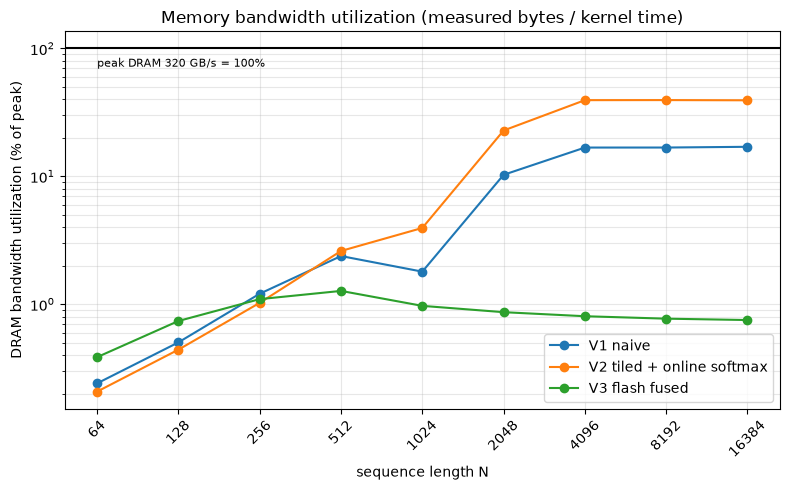

                   version      N    measured  floor x    GB/s  %peak
                  V1 naive  16384   138048 MB  1028.5x    54.5  17.0%
 V2 tiled + online softmax  16384   128185 MB   955.1x   125.9  39.3%
            V3 flash fused  16384     3579 MB    26.7x     2.4   0.8%


In [9]:
# Chart 3 -- DRAM bandwidth utilization: measured bytes (ncu, clock-
# independent) over kernel-only time (CUDA events, boost clocks), % of peak.
# Raw byte counts and floor ratios are in the table below.
if cuda.is_available():
    import json, os, subprocess, sys
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    if not prof_path.exists():  # counters are root-gated: one-off sudo step
        cmd = ([] if os.geteuid() == 0 else ["sudo", "-n"]) + \
              [sys.executable, "src/dram_profile.py", "collect"]
        try:
            subprocess.run(cmd, check=True)
        except (subprocess.CalledProcessError, FileNotFoundError, PermissionError):
            print("no dram_profile.json and no counter access here -- run:")
            print("  sudo .venv/bin/python src/dram_profile.py collect")

    if prof_path.exists():
        prof = json.loads(prof_path.read_text())
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        bw = bench.gpu_specs()["bw_gbs"]
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            tmap = dict(zip(KERNEL_LENS, ktimes[name]))  # KeyError = stale json
            util = [100.0 * r["dram_bytes"] / (tmap[r["n"]] / 1e3) / 1e9 / bw
                    for r in rows]
            ax.plot([r["n"] for r in rows], util, marker="o", color=COLORS[name],
                    label=name)
        ax.axhline(100.0, color="k", lw=1.5)
        ax.text(KERNEL_LENS[0], 72, f"peak DRAM {bw:.0f} GB/s = 100%", fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(KERNEL_LENS, KERNEL_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("DRAM bandwidth utilization (% of peak)")
        ax.set_title("Memory bandwidth utilization (measured bytes / kernel time)")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"{'version':>26} {'N':>6} {'measured':>11} {'floor x':>8} "
              f"{'GB/s':>7} {'%peak':>6}")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            t_s = ktimes[pnames[key]][-1] / 1e3
            gbs = r["dram_bytes"] / t_s / 1e9
            floor = bench.attention_bytes(cpu_model, r["n"])
            print(f"{pnames[key]:>26} {r['n']:>6} {r['dram_bytes'] / 1e6:>8.0f} MB "
                  f"{r['dram_bytes'] / floor:>7.1f}x {gbs:>7.1f} {100 * gbs * 1e9 / (bw * 1e9):>5.1f}%")
else:
    print("No CUDA device -- skipping the bandwidth chart")

## Memory footprint — O(N²) vs O(N)

Traffic explains speed; footprint decides feasibility. The unfused versions
materialise the N×N score and weight matrices — $2 N^2 \cdot 4$ bytes
beyond the inputs, quadrupling with every doubling of N — while V3 streams
tiles and allocates only the [N, D] output. Measured as the torch
allocator's high-water mark over one pass, GPU versions only, swept to
$N = 2^{14}$ where the quadratic footprint already exceeds V3's by three
orders of magnitude.

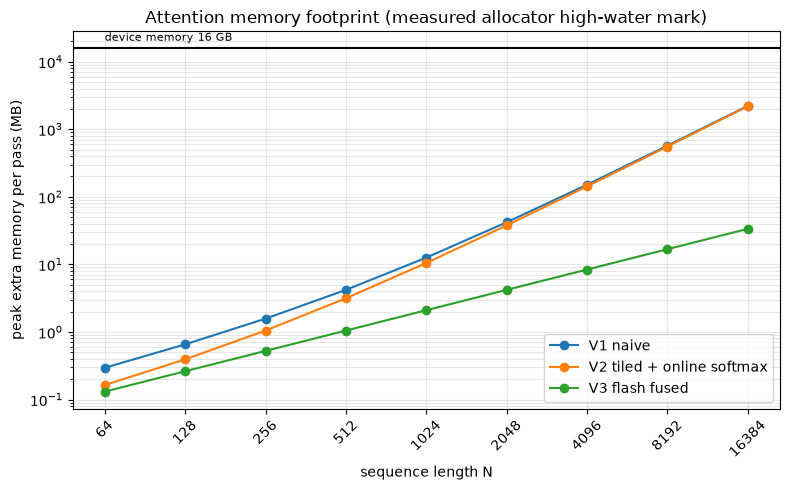

                  V1 naive: fits to N = 16384
 V2 tiled + online softmax: fits to N = 16384
            V3 flash fused: fits to N = 16384


In [10]:
# Chart 4 -- peak extra GPU memory of one attention pass, swept until the
# O(N^2) versions hit the card's capacity. None (OOM) ends a line.
if cuda.is_available():
    FOOT_LENS = KERNEL_LENS  # 64 .. 16384, GPU versions only
    foot_models = {"V1 naive": GpuV1(), "V2 tiled + online softmax": GpuV2(),
                   "V3 flash fused": GpuV3()}
    foot = {name: [] for name in foot_models}
    for n in FOOT_LENS:
        for name, m in foot_models.items():
            foot[name].append(bench.attention_peak_extra_bytes(m, n))
        torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, vals in foot.items():
        pts = [(n, b) for n, b in zip(FOOT_LENS, vals) if b is not None]
        xs, ys = [p[0] for p in pts], [p[1] / 1e6 for p in pts]
        ax.plot(xs, ys, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-", label=name)
        if len(pts) < len(FOOT_LENS):  # line ends where the alloc stopped fitting
            ax.text(xs[-1] * 1.2, ys[-1], f"OOM @ {FOOT_LENS[len(pts)]}",
                    color=COLORS[name], fontsize=8, va="center")
    total = torch.cuda.get_device_properties(0).total_memory
    ax.axhline(total / 1e6, color="k", lw=1.5)
    ax.text(FOOT_LENS[0], total / 1e6 * 1.3, f"device memory {total / 1e9:.0f} GB",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(FOOT_LENS, FOOT_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("peak extra memory per pass (MB)")
    ax.set_title("Attention memory footprint (measured allocator high-water mark)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for name, vals in foot.items():
        fit = sum(b is not None for b in vals)
        print(f"{name:>26}: fits to N = {FOOT_LENS[fit - 1]}"
              + ("" if fit == len(FOOT_LENS) else f", OOM at N = {FOOT_LENS[fit]}"))
else:
    print("No CUDA device -- skipping the footprint sweep")

## Compute throughput — achieved FLOP/s

The same counters, as a rate: executed fp32 operations (ncu SASS
thread-instruction counts, fadd + fmul + 2·ffma, predicated-on lanes) over
the boost-clock kernel time, against the T4's fp32 ceiling — GPU-only, to
$N = 2^{14}$. The counts and their ratio to the $4N^2D$ algorithmic floor
stay in the table, and the ratios are the punchline: V1 and V2 execute
within ~2% of the floor, while V3's per-tile rescale-and-renormalise costs
1.08× — the non-matmul FLOPs FA-2's deferred normalisation later removed.
(`exp()` runs on the SFU, which Turing exposes no per-op counter for, so it
is absent from every version's count.)

The rate view says who feeds the pipes: V1 sustains ~2.7% of fp32 peak
(reuse-free loads starve it), V2's tiles lift that to ~6.6%, and V3 lands
at ~4.9% — its shared-memory block matmuls beat V1 but pay the fusion
machinery. Turing has no fp32 tensor-core path, so the ceiling is the
CUDA-core one; the distance to it is what register micro-tiling, vectorized
loads and software pipelining would buy.

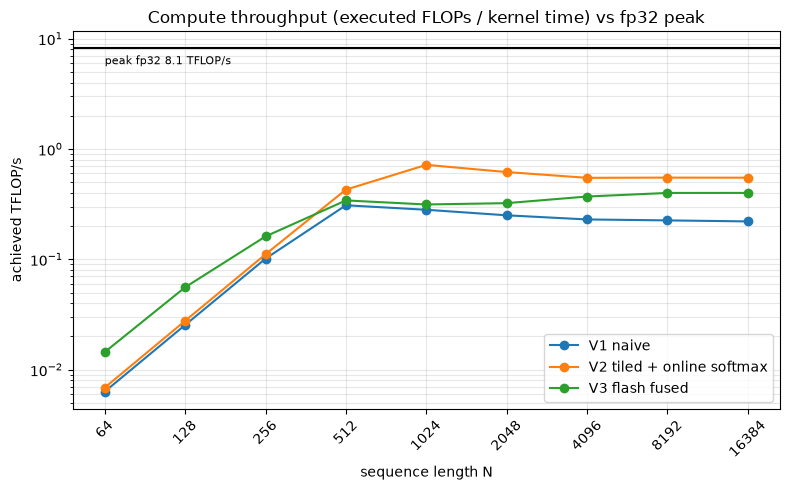

                   version      N      executed  floor x  TFLOP/s  %peak
                  V1 naive  16384  558.90 GFLOP   1.017x     0.22   2.7%
 V2 tiled + online softmax  16384  559.04 GFLOP   1.017x     0.55   6.7%
            V3 flash fused  16384  595.12 GFLOP   1.083x     0.40   4.9%


In [11]:
# Chart 5 -- achieved FLOP/s: executed fp32 ops (ncu SASS counters) over
# kernel-only time (CUDA events), against the fp32 ceiling. Counts and
# floor ratios are in the table below.
if cuda.is_available():
    import json
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        print("dram_profile.json lacks FLOP counters -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused"}
        specs = bench.gpu_specs()
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            tmap = dict(zip(KERNEL_LENS, ktimes[name]))  # KeyError = stale json
            tflops = [r["flops"] / (tmap[r["n"]] / 1e3) / 1e12 for r in rows]
            ax.plot([r["n"] for r in rows], tflops, marker="o", color=COLORS[name],
                    label=name)
        ax.axhline(specs["tflops"], color="k", lw=1.5)
        ax.text(KERNEL_LENS[0], specs["tflops"] * 0.72,
                f"peak fp32 {specs['tflops']:.1f} TFLOP/s", fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(KERNEL_LENS, KERNEL_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("achieved TFLOP/s")
        ax.set_title("Compute throughput (executed FLOPs / kernel time) vs fp32 peak")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        floor = {n: bench.attention_flops(cpu_model, n) for n in KERNEL_LENS}
        print(f"{'version':>26} {'N':>6} {'executed':>13} {'floor x':>8} "
              f"{'TFLOP/s':>8} {'%peak':>6}")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            tf = r["flops"] / (ktimes[pnames[key]][-1] / 1e3) / 1e12
            print(f"{pnames[key]:>26} {r['n']:>6} {r['flops'] / 1e9:>7.2f} GFLOP "
                  f"{r['flops'] / floor[r['n']]:>7.3f}x {tf:>8.2f} "
                  f"{100 * tf / specs['tflops']:>5.1f}%")
else:
    print("No CUDA device -- skipping the throughput chart")

## Conclusion

Chart 1 picked the target — the interpreted attention owns ~95–99% of the
naive forward pass at every N, and it is the block's only quadratic step —
and replacing just that step takes N = 4096 attention from ~30 min on the
python-loop baseline to 70 ms with V2, transfers included (~2.6×10⁴×; V3
lands ~1.6×10⁴×, naive V1 ~1.1×10⁴×). The headline is against a
deliberately sequential interpreter: it measures what leaving Python is
worth, with torch SDPA kept only as the correctness oracle every version
must match within 1e-4.

The kernel ladder is a memory story told twice. Chart 2 shows the speed
rungs: V1 is coalesced but reuse-free — every matmul operand is re-read
from global memory per output element — while V2's 16×16 shared-memory
tiles request ~16× fewer bytes for the same math and its one-pass online
softmax replaces V1's three passes over the row: ~2.5× over V1
kernel-to-kernel at N = 16384 (2.53 vs 1.02 s) and the fastest kernel from
N = 512 up. Charts 3–5 (GPU-only, swept to $2^{14}$) show what tiling does
and doesn't change: both unfused versions drag ~1000× the compulsory floor
in DRAM traffic (128–138 GB per pass at N = 16384) — tiling economises
on-chip requests, not bus bytes — and V2, fast enough for its traffic to
bite, is the heavier bus user (~39% of peak vs V1's ~17%). V3 — the
FlashAttention-1 forward: resident Q tile, one fused kernel, per-tile
online softmax that rescales and renormalises the running output — deletes
the N×N traffic instead: 3.6 GB (27× the floor, ~36× fewer bytes than
either), a footprint that stays O(N) while the unfused intermediates
quadruple with every doubling (Chart 4), and ~1% of the bus — its bytes
ride a slower fused kernel whose matmuls live in shared memory.
Kernel-to-kernel V3 sits between the rungs (1.49 s at N = 16384: ahead of
V1 everywhere, behind V2 past N = 256 — Chart 5's 1.08× FLOP floor from
the per-tile rescale-divides, plus the 33 KB resident tile's
one-block-per-SM occupancy, are the price of fusion).

All three versions run far from the fp32 ceiling — V1 at 2.7% of peak, V3
at 4.9%, V2 at 6.7% — and on this card the remaining distance is not
algorithmic: it is register micro-tiling, vectorized loads and software
pipelining, the machinery of production GEMMs, unreachable from numba's
scalar fp32 pipeline (Turing has no fp32 tensor-core path). And fusion
cannot be composed from library calls — handing a library the matmuls
means materialising N×N, the very thing V3 exists to avoid — so a fused
kernel must bring its own matmul: V3's costs it speed against V2 and buys
the only footprint that scales. The ladder ends where the programming
model does.